👀 Primer vistazo a los datos:


,Edad,Genero,Peso_kg,Estatura_cm,IMC,Cintura_cm,Colesterol_Total,Fumador,Riesgo_Hipertension
0,22.0,1.0,69.2,172.3,23.3,81.0,168.0,2.0,1
1,14.0,1.0,49.4,168.9,17.3,64.6,154.0,2.0,0
2,44.0,2.0,67.2,170.1,23.2,80.1,190.0,2.0,0
3,14.0,2.0,69.1,159.4,27.2,86.7,161.0,2.0,0
4,9.0,1.0,28.8,133.4,16.2,59.8,177.0,2.0,0



📊 Distribución de la variable objetivo (Hipertensión):
Riesgo_Hipertension
0    67.63 %
1    32.37 %
Name: proportion, dtype: object


[06/23/26 12:05:33] WARNING  C:\Users\maico\AppData\Local\Temp\ipykernel_23832\4128886429.py:21:    ]8;id=13864582;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=13864583;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.boxplot(x='Riesgo_Hipertension', y='Edad', data=df,                             
                             palette='Set2')                                                                       
                                                                                                                   

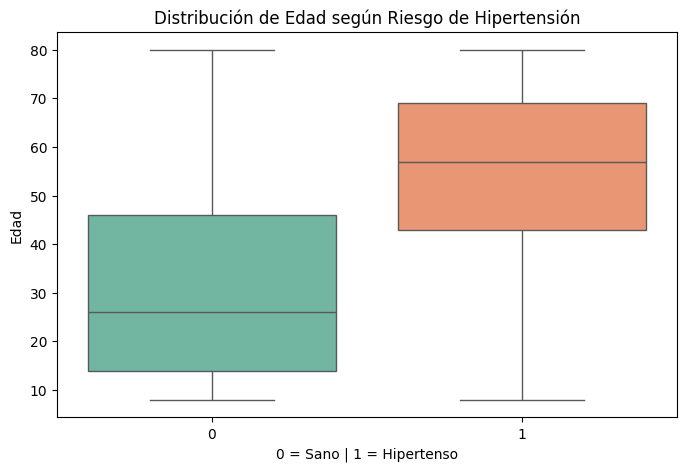

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar tu dataset limpio (ajusta la ruta según donde estés parado)
# Como el notebook suele estar en una subcarpeta, usamos '../' para retroceder
ruta_archivo = "../data/02_intermediate/df_nhanes_limpio.csv"
df = pd.read_csv(ruta_archivo)

# 2. Ver las primeras 5 filas para confirmar las columnas en español
print("👀 Primer vistazo a los datos:")
display(df.head())

# 3. Ver cuántos hipertensos (1) vs sanos (0) tenemos
print("\n📊 Distribución de la variable objetivo (Hipertensión):")
distribucion = df['Riesgo_Hipertension'].value_counts(normalize=True) * 100
print(distribucion.round(2).astype(str) + ' %')

# 4. Un gráfico rápido de Edad vs Riesgo
plt.figure(figsize=(8, 5))
sns.boxplot(x='Riesgo_Hipertension', y='Edad', data=df, palette='Set2')
plt.title('Distribución de Edad según Riesgo de Hipertensión')
plt.xlabel('0 = Sano | 1 = Hipertenso')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("🧠 Iniciando entrenamiento del modelo...")

# 1. Separar características (X) y la etiqueta a predecir (y)
X = df.drop(columns=['Riesgo_Hipertension'])
y = df['Riesgo_Hipertension']

# 2. Dividir datos: 80% para entrenar (estudiar) y 20% para probar (examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y Entrenar el Modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Hacer que el modelo rinda el "examen" con el 20% de datos que no conoce
predicciones = modelo.predict(X_test)
precision = accuracy_score(y_test, predicciones) * 100

print(f"\n✅ ¡Entrenamiento completado!")
print(f"🎯 Precisión Global del Modelo: {precision:.2f}%\n")

print("📊 Reporte detallado de clasificación:")
print(classification_report(y_test, predicciones))

🧠 Iniciando entrenamiento del modelo...

✅ ¡Entrenamiento completado!
🎯 Precisión Global del Modelo: 73.22%

📊 Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      3725
           1       0.58      0.56      0.57      1750

    accuracy                           0.73      5475
   macro avg       0.69      0.69      0.69      5475
weighted avg       0.73      0.73      0.73      5475



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Asegurar la división de datos (por si acaso limpiaste memoria)
X = df.drop(columns=['Riesgo_Hipertension'])
y = df['Riesgo_Hipertension']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("⚖️ Modelo 1: Random Forest Clínico (Con pesaje balanceado)")
# Al agregar class_weight='balanced', el modelo penaliza el doble si se equivoca con un hipertenso
rf_balanceado = RandomForestClassifier(n_estimators=150, class_weight='balanced', max_depth=10, random_state=42)
rf_balanceado.fit(X_train, y_train)
preds_rf = rf_balanceado.fit(X_train, y_train).predict(X_test)

print("⚡ Modelo 2: Gradient Boosting (Aprendizaje secuencial)")
# Este algoritmo no usa pesos, sino que se enfoca en las filas difíciles en cada ronda
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gbm.fit(X_train, y_train)
preds_gbm = gbm.predict(X_test)

print("\n" + "="*50)
print("📊 RESULTADOS DEL COMPARATIVO DE MODELOS")
print("="*50)

print(f"\n🏆 RANDOM FOREST BALANCEADO (Accuracy: {accuracy_score(y_test, preds_rf)*100:.2f}%)")
print(classification_report(y_test, preds_rf))

print(f"\n🏆 GRADIENT BOOSTING (Accuracy: {accuracy_score(y_test, preds_gbm)*100:.2f}%)")
print(classification_report(y_test, preds_gbm))

⚖️ Modelo 1: Random Forest Clínico (Con pesaje balanceado)
⚡ Modelo 2: Gradient Boosting (Aprendizaje secuencial)

📊 RESULTADOS DEL COMPARATIVO DE MODELOS

🏆 RANDOM FOREST BALANCEADO (Accuracy: 72.68%)
              precision    recall  f1-score   support

           0       0.90      0.68      0.77      3725
           1       0.55      0.83      0.66      1750

    accuracy                           0.73      5475
   macro avg       0.72      0.76      0.72      5475
weighted avg       0.79      0.73      0.74      5475


🏆 GRADIENT BOOSTING (Accuracy: 75.12%)
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      3725
           1       0.60      0.65      0.63      1750

    accuracy                           0.75      5475
   macro avg       0.72      0.73      0.72      5475
weighted avg       0.76      0.75      0.75      5475



In [4]:
from sklearn.model_selection import GridSearchCV

print("⚙️ Iniciando la búsqueda de la mejor configuración (Hyperparameter Tuning)...")

# 1. Definimos las "perillas" y los valores que queremos probar
param_grid = {
    'n_estimators': [100, 150, 200],         # Cantidad de árboles en el bosque
    'max_depth': [6, 8, 10, 12],             # Qué tan profundo/complejo puede ser cada árbol
    'min_samples_split': [2, 5, 10],          # Cuántos pacientes mínimos se necesitan para dividir un nodo
    'class_weight': ['balanced']             # Mantener nuestro escudo para proteger a los enfermos
}

# 2. Creamos un modelo base
rf_base = RandomForestClassifier(random_state=42)

# 3. Configuramos GridSearch para que evalúe basándose en el 'recall' (para no perder hipertensos)
# cv=3 significa que probará cada combinación 3 veces con diferentes pedazos de datos (Cross-Validation)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           scoring='recall', cv=3, n_jobs=-1, verbose=1)

# 4. ¡A buscar!
grid_search.fit(X_train, y_train)

print("\n🏆 ¡Búsqueda terminada!")
print("Mejor configuración encontrada:", grid_search.best_params_)

# 5. Evaluar el súper-modelo optimizado en los datos de prueba
mejor_modelo = grid_search.best_estimator_
preds_optimizadas = mejor_modelo.predict(X_test)

print("\n📊 Reporte del modelo final optimizado:")
print(classification_report(y_test, preds_optimizadas))

⚙️ Iniciando la búsqueda de la mejor configuración (Hyperparameter Tuning)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 ¡Búsqueda terminada!
Mejor configuración encontrada: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200}

📊 Reporte del modelo final optimizado:
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      3725
           1       0.53      0.87      0.66      1750

    accuracy                           0.72      5475
   macro avg       0.72      0.76      0.71      5475
weighted avg       0.79      0.72      0.73      5475



In [5]:
!pip install optuna

     ---------------------------------------- 0.0/425.6 kB ? eta -:--:--
     --- --------------------------------- 41.0/425.6 kB 991.0 kB/s eta 0:00:01
     -------- ------------------------------ 92.2/425.6 kB 1.3 MB/s eta 0:00:01
     ------------ ------------------------- 143.4/425.6 kB 1.4 MB/s eta 0:00:01
     ------------------------ ------------- 276.5/425.6 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 425.6/425.6 kB 2.0 MB/s eta 0:00:00
  Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
     ---------------------------------------- 0.0/78.3 kB ? eta -:--:--
     ---------------------------------------- 78.3/78.3 kB ? eta 0:00:00
  Using cached mako-1.3.12-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, classification_report
import logging

# Silenciar los logs repetitivos de Optuna para que el notebook quede limpio
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("🎯 Iniciando la optimización inteligente con Optuna...")

# 1. Definir la función objetivo (lo que Optuna intentará mejorar)
def objetivo(trial):
    # Le damos rangos dinámicos a Optuna para que busque con libertad
    hiperparametros = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Crear y entrenar el modelo con la sugerencia de este intento
    modelo = RandomForestClassifier(**hiperparametros)
    modelo.fit(X_train, y_train)
    
    # Evaluar las predicciones
    preds = modelo.predict(X_test)
    
    # Retornamos el recall de la clase 1 (Hipertensos) para que Optuna lo maximice
    return recall_score(y_test, preds, pos_label=1)

# 2. Crear el estudio de Optuna (dirección: maximizar)
estudio = optuna.create_study(direction='maximize')

# 3. Lanzar 30 pruebas (trials). Optuna aprenderá de cada una de ellas.
estudio.optimize(objetivo, n_trials=30)

print("\n🏆 ¡Optimización de Optuna completada!")
print("Mejores parámetros encontrados:", estudio.best_params)
print(f"Mejor Recall alcanzado: {estudio.best_value*100:.2f}%")

# 4. Entrenar el modelo final con el "traje a la medida" que descubrió Optuna
mejor_config = {**estudio.best_params, 'class_weight': 'balanced', 'random_state': 42}
modelo_optuna = RandomForestClassifier(**mejor_config)
modelo_optuna.fit(X_train, y_train)

# 5. Reporte de Clasificación Final
preds_finales = modelo_optuna.predict(X_test)
print("\n📊 Reporte del Súper-Modelo de Optuna:")
print(classification_report(y_test, preds_finales))

[06/23/26 12:14:00] WARNING  C:\Users\maico\Proyectos\nhanes-pipeline\.venv\lib\site-packages\tqdm\ ]8;id=13864588;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=13864589;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             auto.py:21: TqdmWarning: IProgress not found. Please update jupyter                   
                             and ipywidgets. See                                                                   
                             https://ipywidgets.readthedocs.io/en/stable/user_install.html                         
                               from .autonotebook import tqdm as notebook_tqdm                                     
                                                                                                                   

🎯 Iniciando la optimización inteligente con Optuna...

🏆 ¡Optimización de Optuna completada!
Mejores parámetros encontrados: {'n_estimators': 135, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 9}
Mejor Recall alcanzado: 87.89%

📊 Reporte del Súper-Modelo de Optuna:
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      3725
           1       0.53      0.88      0.66      1750

    accuracy                           0.71      5475
   macro avg       0.72      0.76      0.71      5475
weighted avg       0.79      0.71      0.72      5475



In [7]:
import numpy as np
from sklearn.metrics import classification_report

print("🎛️ Ajustando la exigencia del modelo...\n")

# 1. En lugar de pedirle 0s y 1s, le pedimos los porcentajes de seguridad (probabilidades)
probabilidades = modelo_optuna.predict_proba(X_test)[:, 1] 

# 2. Definimos nuestra nueva vara de exigencia (Umbral del 60% en lugar del 50%)
nuevo_umbral = 0.60

# 3. Aplicamos la regla: Solo será 1 si la probabilidad supera el nuevo_umbral
predicciones_exigentes = (probabilidades >= nuevo_umbral).astype(int)

# 4. Vemos el nuevo resultado
print(f"📊 Resultados con una exigencia del {nuevo_umbral*100}%:")
print(classification_report(y_test, predicciones_exigentes))

🎛️ Ajustando la exigencia del modelo...

📊 Resultados con una exigencia del 60.0%:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79      3725
           1       0.57      0.78      0.66      1750

    accuracy                           0.74      5475
   macro avg       0.72      0.75      0.72      5475
weighted avg       0.78      0.74      0.75      5475



🔍 Analizando el cerebro del modelo...

📊 Ranking de Variables (0 significa que no sirve, 1 es el máximo):
        Variable  Importancia
            Edad     0.502913
      Cintura_cm     0.205582
         Peso_kg     0.102785
             IMC     0.072552
     Estatura_cm     0.036819
Colesterol_Total     0.035887
         Fumador     0.030787
          Genero     0.012675


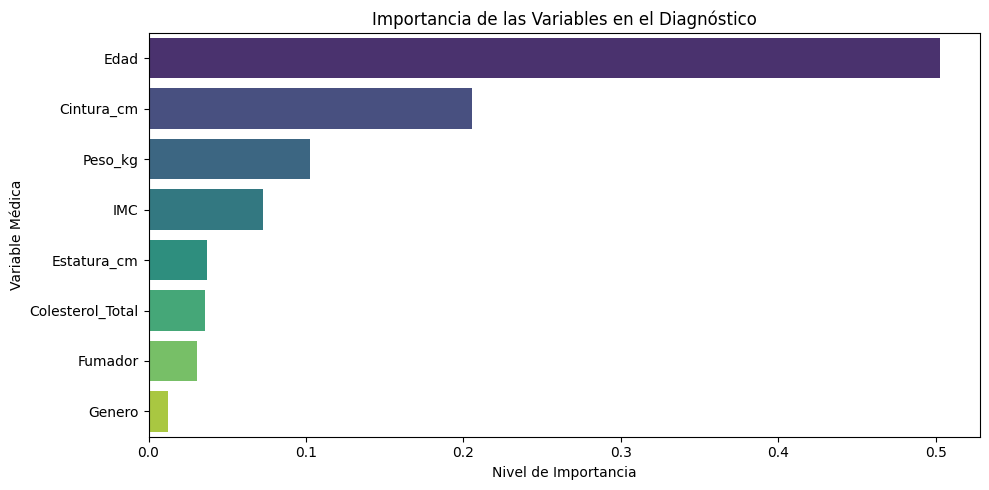


🗑️ El modelo dice que estas 2 variables son casi 'ruido': ['Fumador', 'Genero']
¡Vamos a eliminarlas y re-entrenar para ver qué pasa!

📈 Reporte del Modelo con Datos Limpios (Sin Ruido):
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      3725
           1       0.53      0.86      0.66      1750

    accuracy                           0.72      5475
   macro avg       0.72      0.75      0.71      5475
weighted avg       0.79      0.72      0.73      5475



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

print("🔍 Analizando el cerebro del modelo...\n")

# 1. Extraer la importancia de las variables de tu mejor modelo (el de Optuna)
importancias = modelo_optuna.feature_importances_
columnas = X_train.columns

# 2. Crear una tabla ordenada de mayor a menor importancia
df_importancias = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

print("📊 Ranking de Variables (0 significa que no sirve, 1 es el máximo):")
print(df_importancias.to_string(index=False))

# 3. Dibujar el gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, hue='Variable', palette='viridis', legend=False)
plt.title('Importancia de las Variables en el Diagnóstico')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable Médica')
plt.tight_layout()
plt.show()

# 4. EL EXPERIMENTO: Quitar las 2 peores variables
variables_basura = df_importancias['Variable'].tail(2).tolist()
print(f"\n🗑️ El modelo dice que estas 2 variables son casi 'ruido': {variables_basura}")
print("¡Vamos a eliminarlas y re-entrenar para ver qué pasa!")

# 5. Crear nuevos datos sin el ruido
X_train_limpio = X_train.drop(columns=variables_basura)
X_test_limpio = X_test.drop(columns=variables_basura)

# 6. Re-entrenar usando tu configuración ganadora de Optuna
modelo_limpio = RandomForestClassifier(**mejor_config)
modelo_limpio.fit(X_train_limpio, y_train)

# 7. Nuevo Reporte
preds_limpias = modelo_limpio.predict(X_test_limpio)
print("\n📈 Reporte del Modelo con Datos Limpios (Sin Ruido):")
print(classification_report(y_test, preds_limpias))

In [9]:
# 1. Instalar XGBoost (si estás en Google Colab o tu entorno no lo tiene)
!pip install xgboost

import xgboost as xgb
from sklearn.metrics import classification_report

print("\n🚀 Iniciando entrenamiento con XGBoost...\n")

# 2. Calcular la proporción exacta para el pesaje de pacientes (Sanos / Enfermos)
# Esto es el equivalente matemático al class_weight='balanced'
sanos = (y_train == 0).sum()
enfermos = (y_train == 1).sum()
ratio_desbalance = sanos / enfermos

# 3. Configurar el modelo XGBoost
# Usamos parámetros iniciales conservadores para evitar el overfitting
modelo_xgb = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=ratio_desbalance, # El escudo para proteger a los hipertensos
    random_state=42,
    n_jobs=-1
)

# 4. Entrenar el modelo
modelo_xgb.fit(X_train, y_train)

# 5. Predecir y evaluar
preds_xgb = modelo_xgb.predict(X_test)

print("🏆 Reporte del Modelo XGBoost:")
print(classification_report(y_test, preds_xgb))


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     -------------------------------------- 0.1/101.7 MB 871.5 kB/s eta 0:01:57
     ---------------------------------------- 0.2/101.7 MB 1.0 MB/s eta 0:01:40
     ---------------------------------------- 0.3/101.7 MB 1.6 MB/s eta 0:01:04
     ---------------------------------------- 0.5/101.7 MB 1.8 MB/s eta 0:00:57
     ---------------------------------------- 0.6/101.7 MB 2.2 MB/s eta 0:00:47
     ---------------------------------------- 0.8/101.7 MB 2.5 MB/s eta 0:00:40
     ---------------------------------------- 1.1/101.7 MB 2.9 MB/s eta 0:00:35
      --------------------------------------- 1.3/101.7 MB 3.2 MB/s eta 0:00:32
      --------------------------------------- 1.7/101.7 MB 3.6 MB/s eta 0:00:28
      --------------------------------------- 1.9/101.7 MB 3.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🩸 Iniciando el predictor de Colesterol...\n")

# 1. Volvemos a armar nuestra X (datos) e y (objetivo)
# NOTA: Asegúrate de cambiar 'df' por el nombre real de tu tabla de datos original
X_reg = df.drop(columns=['Colesterol_Total']) 
y_reg = df['Colesterol_Total']

# 2. Partimos los datos (80% estudiar, 20% examen final)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Llamamos al modelo de Regresión
modelo_colesterol = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)

# 4. Lo ponemos a estudiar
modelo_colesterol.fit(X_train_r, y_train_r)

# 5. Le pedimos que adivine el colesterol de los pacientes del examen final
predicciones_colesterol = modelo_colesterol.predict(X_test_r)

# 6. Evaluamos qué tan bien le fue
error_promedio = mean_absolute_error(y_test_r, predicciones_colesterol)
r2 = r2_score(y_test_r, predicciones_colesterol)

print(f"📉 Error Absoluto Medio (MAE): Me equivoco por {error_promedio:.2f} mg/dL en promedio.")
print(f"📊 R-Cuadrado (R2): {r2:.2f} (1.0 es perfecto, 0 es adivinar al azar)")

# 7. Bonus: Ver las variables más importantes para adivinar el colesterol
importancias_reg = pd.DataFrame({
    'Variable': X_reg.columns, 
    'Importancia': modelo_colesterol.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n🔍 Lo que más influye en el Colesterol según el modelo:")
print(importancias_reg.to_string(index=False))

🩸 Iniciando el predictor de Colesterol...

📉 Error Absoluto Medio (MAE): Me equivoco por 26.93 mg/dL en promedio.
📊 R-Cuadrado (R2): 0.19 (1.0 es perfecto, 0 es adivinar al azar)

🔍 Lo que más influye en el Colesterol según el modelo:
           Variable  Importancia
               Edad     0.685393
         Cintura_cm     0.095248
             Genero     0.067345
        Estatura_cm     0.057007
            Peso_kg     0.044100
                IMC     0.035857
Riesgo_Hipertension     0.012317
            Fumador     0.002732
